## YOLOv11을 활용한 객체 탐지 및 신뢰도 출력

### 1단계 : 환경 설정 및 라이브러리 설치 

In [4]:
!pip install ultralytics opencv-python matplotlib

In [13]:
%matplotlib inline 
# 중간 출력 정상화 
import pandas as pd 
import numpy as np

import ultralytics
import cv2 
import os
# 파일 저장 경로 활성화

import yaml  # 설정 파일(.yaml)을 다루기 위한 라이브러리
import glob
import torch # GPU 확인
import urllib.request
# 잘 설치되었는지 버전 확인

# 시각화 
from IPython.display import display, Image
import matplotlib.pyplot as plt

# 한글 패치 표준

plt.rcParams['font.family'] = 'Malgun Gothic' # apple : 'AppleGothic'

# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [11]:
print(f"Ultralytics version: {ultralytics.__version__}")

Ultralytics version: 8.4.90


### YOLOv11 모델 로드 및 학습 

In [16]:
from ultralytics import YOLO  # YOLO 모델 클래스 로드

model = YOLO('yolo11n.pt') # nano 모델 ( 경량 모델 )

model.train(data='coco128.yaml',epochs=3 ,imgsz=640)

Ultralytics 8.4.90  Python-3.13.9 torch-2.13.0+cpu CPU (12th Gen Intel Core i5-12500H)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspectiv

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 11, 13, 14, 15, 16, 17, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 38, 39, 40, 41, 42, 43, 44, 45, 46, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 67, 68, 69, 71, 72, 73, 74, 75, 76, 77, 79])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000013CED23B5C0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027

yaml : 이미지 객체 정보를 담고 있는 데이터 , 실무에서는 지정해서 사용 

### 3단계 학습 결과 및 모델 검증 

In [17]:
metrics = model.val()

print(f"검증 결과 - 평균 정밀도 : {metrics.box.map:.4f}")
print(f"검증 결과 - IOU 0.5일때의 정밀도 : {metrics.box.map50:.4f}") # Detection 민감도 지표 IOU

Ultralytics 8.4.90  Python-3.13.9 torch-2.13.0+cpu CPU (12th Gen Intel Core i5-12500H)
YOLO11n summary (fused): 101 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 146.496.0 MB/s, size: 42.2 KB)
val: Scanning C:\Users\cyj01\OneDrive\Desktop\AI_Industry\DL\datasets\coco128\labels\train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 29.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.9s/it 15.2s2.2s
                   all        128        929      0.743      0.592      0.687      0.517
                person         61        254      0.835      0.656      0.786       0.54
               bicycle          3          6      0.592      0.167      0.397      0.261
                   car         12         46      0.758      0.205      0.264      0.182
            motorcycle          4          5       0.73          1      0.995     

### 4단계 : 테스트 이미지 추론 및 시각화 


image 1/1 C:\Users\cyj01\OneDrive\Desktop\AI_Industry\DL\datasets\coco128\images\train2017\000000000036.jpg: 640x512 1 person, 1 umbrella, 276.3ms
Speed: 3.7ms preprocess, 276.3ms inference, 2.6ms postprocess per image at shape (1, 3, 640, 512)


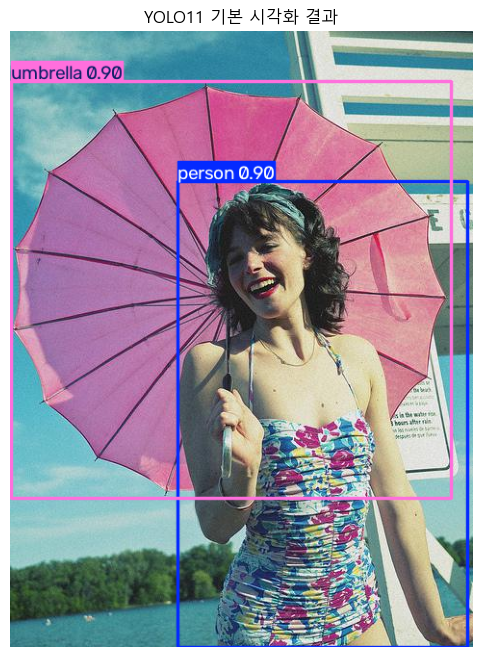

In [23]:
from ultralytics import settings
# coco8 데이터셋이 설치된 로컬 실제 경로를 동적으로 가져옵니다.
datasets_root = settings.get('datasets_dir', 'datasets')
test_image_path = os.path.join(datasets_root, 'coco128', 'images', 'train2017', '000000000036.jpg')

if os.path.exists(test_image_path):
    # 모델 추론 수행
    results = model(test_image_path)
    
    # 탐지 결과를 바운딩 박스가 그려진 이미지 형태로 가져옵니다.
    annotated_image = results[0].plot()
    
    # OpenCV는 BGR 형식을 사용하지만 Matplotlib은 RGB 형식을 사용하므로 변환해 줍니다.
    annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)
    
    # 결과 이미지 출력
    plt.figure(figsize=(10, 8))
    plt.imshow(annotated_image_rgb)
    plt.axis('off')
    plt.title("YOLO11 기본 시각화 결과")
    plt.show()  # 이미지를 브라우저/에디터에 즉시 출력 보장
else:
    print(f"[안내] 테스트 이미지 경로를 찾을 수 없습니다. 경로를 확인해 주세요. 경로: {test_image_path}")

In [20]:
def detect_objects_and_show_confidence(image_path, model_path='yolo11n.pt'):
    """
    로컬 이미지를 불러와 YOLO11 모델로 객체를 탐지하고,
    신뢰도(Confidence Score)가 포함된 레이블과 바운딩 박스를 직접 그려서 시각화합니다.
    
    :param image_path: 로컬 이미지 파일 경로
    :param model_path: 사용할 YOLO 모델 가중치 파일 경로 (학습한 모델을 사용하려면 'runs/detect/train/weights/best.pt')
    """
    # 1. 모델 로드
    # 훈련 단계에서 얻은 최고 성능의 가중치가 있다면 그것을 로드하고, 없으면 기본 YOLO11n 모델을 사용합니다.
    print(f"[{model_path}] 가중치 모델 로딩 중...")
    model = YOLO(model_path)
    
    # 2. 로컬 이미지 읽기
    img = cv2.imread(image_path)
    if img is None:
        print(f"[오류] 이미지를 불러올 수 없습니다. 경로를 확인해 주세요: {image_path}")
        return
    
    # 시각화할 도화지 이미지 생성 (원본 이미지 복사)
    output_img = img.copy()
    
    # 3. 객체 탐지(Object Detection) 수행
    # conf=0.25 옵션은 신뢰도(Confidence Score)가 25% 이상인 객체만 검출하도록 설정합니다.
    results = model(img, conf=0.25)[0]
    
    print(f"\n=== [{os.path.basename(image_path)}] 탐지 결과 리스트 ===")
    
    # 4. 검출된 객체 정보를 순회하며 분석 및 드로잉
    # results.boxes에는 각 검출된 사물 정보가 들어 있습니다.
    for i, box in enumerate(results.boxes):
        # 좌상단 좌표(x1, y1), 우하단 좌표(x2, y2) 추출 및 정수형 변환
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        
        # 신뢰도(Confidence Score) 추출
        confidence = float(box.conf[0])
        
        # 클래스(Class) 번호 및 클래스명 매핑
        class_id = int(box.cls[0])
        class_name = results.names[class_id]
        
        # 콘솔에 상세 정보 출력
        print(f"[{i+1}] 클래스: {class_name} | 신뢰도(Confidence): {confidence:.4f} | 좌표: [{x1}, {y1}, {x2}, {y2}]")
        
        # 이미지에 바운딩 박스(Bounding Box) 그리기 (초록색 선, 두께 2px)
        cv2.rectangle(output_img, (x1, y1), (x2, y2), (0, 255, 0), 2)
        
        # 화면에 그릴 텍스트 정의 (클래스명과 신뢰도를 백분율 또는 소수점으로 표시)
        label_text = f"{class_name} {confidence:.2f}"
        
        # 텍스트가 박스 바깥(위쪽)으로 너무 벗어나지 않게 처리하면서 가독성 높이기 위해 배경 사각형 영역 계산
        (text_w, text_h), baseline = cv2.getTextSize(label_text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(output_img, (x1, y1 - text_h - 5), (x1 + text_w, y1), (0, 255, 0), cv2.FILLED)
        
        # 검은색 텍스트 그리기
        cv2.putText(output_img, label_text, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1, cv2.LINE_AA)
        
    print("===========================================\n")
    
    # Matplotlib 시각화를 위해 BGR 채널을 RGB 채널로 전환
    output_rgb = cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB)
    
    # 최종 결과 이미지 출력
    plt.figure(figsize=(12, 10))
    plt.imshow(output_rgb)
    plt.title(f"YOLO11 Custom Detection: {os.path.basename(image_path)}")
    plt.axis('off')
    plt.show()

인터넷에서 샘플 이미지를 다운로드 중...
다운로드 완료! 저장 위치: local_test_bus.jpg
[runs/detect/train/weights/best.pt] 가중치 모델 로딩 중...

0: 640x480 4 persons, 1 bus, 1 stop sign, 265.8ms
Speed: 4.9ms preprocess, 265.8ms inference, 2.1ms postprocess per image at shape (1, 3, 640, 480)

=== [local_test_bus.jpg] 탐지 결과 리스트 ===
[1] 클래스: person | 신뢰도(Confidence): 0.8696 | 좌표: [49, 396, 245, 904]
[2] 클래스: bus | 신뢰도(Confidence): 0.8694 | 좌표: [22, 227, 802, 754]
[3] 클래스: person | 신뢰도(Confidence): 0.8461 | 좌표: [670, 380, 809, 875]
[4] 클래스: person | 신뢰도(Confidence): 0.8155 | 좌표: [221, 405, 344, 857]
[5] 클래스: stop sign | 신뢰도(Confidence): 0.4584 | 좌표: [0, 254, 32, 324]
[6] 클래스: person | 신뢰도(Confidence): 0.3339 | 좌표: [0, 550, 65, 874]



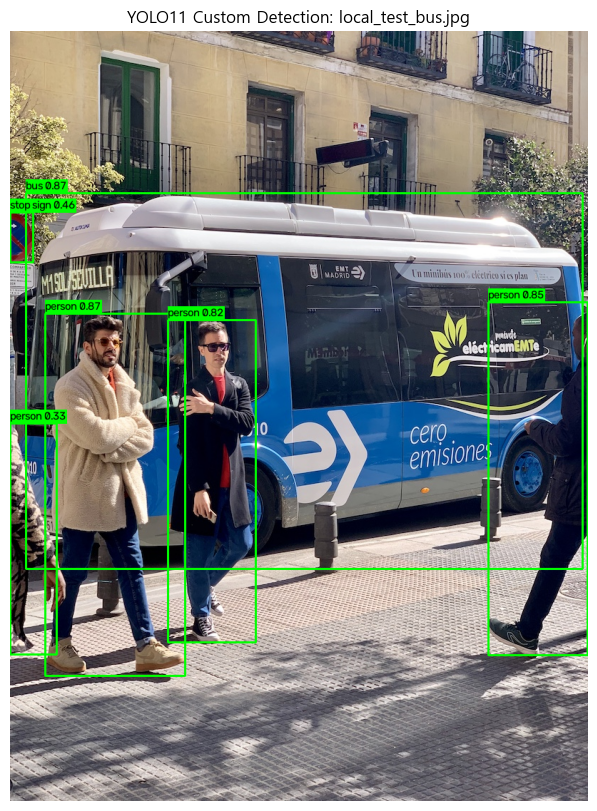

In [21]:
# 테스트용 샘플 이미지 URL (YOLO 공식 샘플 이미지)
sample_url = "https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/bus.jpg"
local_filename = "local_test_bus.jpg"

print("인터넷에서 샘플 이미지를 다운로드 중...")
urllib.request.urlretrieve(sample_url, local_filename)
print(f"다운로드 완료! 저장 위치: {local_filename}")

# 학습한 커스텀 모델의 최고 가중치가 생성되었는지 체크하고,
# 있다면 해당 가중치를 사용하고 없다면 기본 YOLO11n.pt 가중치를 사용하여 테스트합니다.
trained_model_path = 'runs/detect/train/weights/best.pt'
if not os.path.exists(trained_model_path):
    print("[안내] 학습된 가중치 파일(best.pt)이 없어 기본 yolo11n.pt 모델 가중치로 추론을 수행합니다.")
    trained_model_path = 'yolo11n.pt'

# 객체 탐지 실행
detect_objects_and_show_confidence(local_filename, model_path=trained_model_path)